In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
df = pd.read_csv("C:\\Users\\SRIHARINI V\\Downloads\\archive (7)\\student-mat.csv")

In [8]:
df = pd.read_csv("C:\\Users\\SRIHARINI V\\Downloads\\archive (7)\\student-por.csv")

In [9]:
file = open("C:\\Users\\SRIHARINI V\\Downloads\\archive (7)\\student-merge.R", "r") 


In [10]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
 
print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


In [11]:
print("\nFirst 5 rows of the dataset:")
print(df.head())


First 5 rows of the dataset:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  13  12  
3      3        2      2     1     1      5        0  14  14  14  
4      4        3      2     1     2      5        0  11  13  13  

[5 rows x 33 columns]


In [12]:
print("\n" + "="*60)
print("STEP 3: DATA EXPLORATION")
print("="*60)


STEP 3: DATA EXPLORATION


In [13]:
print("\nData Types:")
print(df.dtypes)
 


Data Types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object


In [14]:
print("\n\nMissing Values:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "✓ No missing values!")



Missing Values:
✓ No missing values!


In [15]:
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"✓ Removed {duplicates} duplicate rows. New shape: {df.shape}")


Duplicate rows: 0


In [16]:
print("\n\nBasic Statistics:")
print(df.describe())
 



Basic Statistics:
              age        Medu        Fedu  traveltime   studytime    failures  \
count  649.000000  649.000000  649.000000  649.000000  649.000000  649.000000   
mean    16.744222    2.514638    2.306626    1.568567    1.930663    0.221880   
std      1.218138    1.134552    1.099931    0.748660    0.829510    0.593235   
min     15.000000    0.000000    0.000000    1.000000    1.000000    0.000000   
25%     16.000000    2.000000    1.000000    1.000000    1.000000    0.000000   
50%     17.000000    2.000000    2.000000    1.000000    2.000000    0.000000   
75%     18.000000    4.000000    3.000000    2.000000    2.000000    0.000000   
max     22.000000    4.000000    4.000000    4.000000    4.000000    3.000000   

           famrel    freetime       goout        Dalc        Walc      health  \
count  649.000000  649.000000  649.000000  649.000000  649.000000  649.000000   
mean     3.930663    3.180277    3.184900    1.502311    2.280431    3.536210   
std    

In [17]:
print("\n\nAll Column Names:")
print(df.columns.tolist())



All Column Names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [18]:
print("\n" + "="*60)
print("STEP 4: DATA ANALYSIS - KEY INSIGHTS")
print("="*60)


STEP 4: DATA ANALYSIS - KEY INSIGHTS


In [19]:
avg_grade = df['G3'].mean()
print(f"\n1️⃣  Average Final Grade (G3): {avg_grade:.2f}")


1️⃣  Average Final Grade (G3): 11.91


In [20]:
students_above_15 = (df['G3'] > 15).sum()
percentage = (students_above_15 / len(df)) * 100
print(f"\n2️⃣  Students with grade > 15: {students_above_15} ({percentage:.1f}%)")


2️⃣  Students with grade > 15: 82 (12.6%)


In [21]:
correlation = df['studytime'].corr(df['G3'])
print(f"\n3️⃣  Correlation between Study Time & Final Grade:")
print(f"   Correlation coefficient: {correlation:.3f}")
if correlation > 0.3:
    print("   ✓ Positive correlation (Higher study time → Better grades)")
elif correlation < -0.3:
    print("   ✓ Negative correlation (Higher study time → Lower grades)")
else:
    print("   ✓ Weak correlation (Study time has minimal impact)")
 


3️⃣  Correlation between Study Time & Final Grade:
   Correlation coefficient: 0.250
   ✓ Weak correlation (Study time has minimal impact)


In [22]:
print(f"\n4️⃣  Gender-based Performance Comparison:")
gender_performance = df.groupby('sex')['G3'].agg(['mean', 'median', 'std', 'count'])
print(gender_performance)


4️⃣  Gender-based Performance Comparison:
          mean  median       std  count
sex                                    
F    12.253264    12.0  3.124147    383
M    11.406015    11.0  3.320690    266


In [23]:
avg_by_gender = df.groupby('sex')['G3'].mean()
better_gender = avg_by_gender.idxmax()
print(f"\n   ✓ Best performing gender: {better_gender} (Avg: {avg_by_gender.max():.2f})")
 



   ✓ Best performing gender: F (Avg: 12.25)


In [24]:
print("\n" + "="*60)
print("STEP 5: CREATING VISUALIZATIONS")
print("="*60)


STEP 5: CREATING VISUALIZATIONS


Text(0.5, 0.98, 'Student Performance Analysis Dashboard')

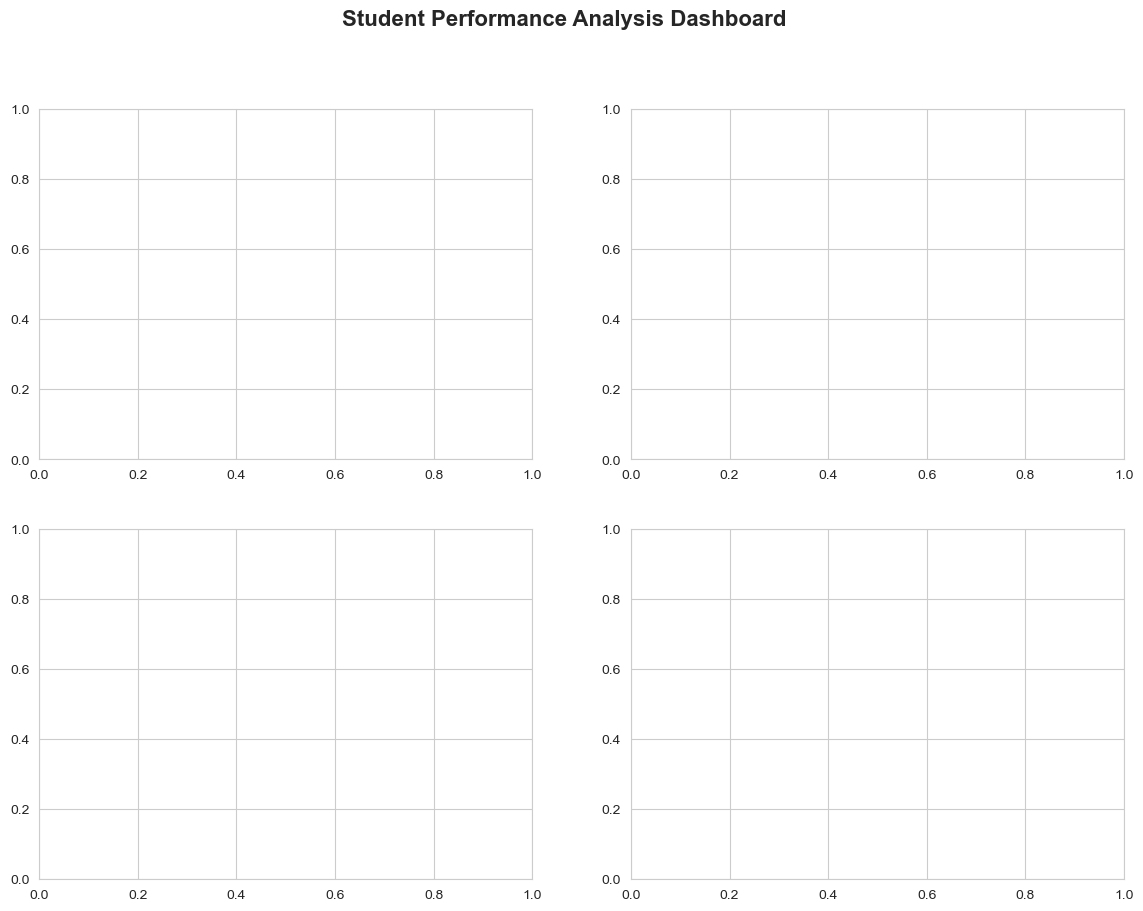

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Student Performance Analysis Dashboard', fontsize=16, fontweight='bold')

In [30]:
axes[0, 0].hist(df['G3'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Final Grade (G3)')
axes[0, 0].set_ylabel('Number of Students')
axes[0, 0].set_title('Distribution of Final Grades')
axes[0, 0].axvline(avg_grade, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_grade:.2f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

In [29]:
axes[0, 1].scatter(df['studytime'], df['G3'], alpha=0.5, color='green')
axes[0, 1].set_xlabel('Study Time')
axes[0, 1].set_ylabel('Final Grade (G3)')
axes[0, 1].set_title(f'Study Time vs Final Grade\n(Correlation: {correlation:.3f})')

Text(0.5, 1.0, 'Study Time vs Final Grade\n(Correlation: 0.250)')

In [31]:
z = np.polyfit(df['studytime'], df['G3'], 1)
p = np.poly1d(z)
axes[0, 1].plot(df['studytime'].sort_values(), p(df['studytime'].sort_values()), 
                "r--", linewidth=2, label='Trend line')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

In [32]:
gender_avg = df.groupby('sex')['G3'].mean()
colors_bar = ['#FF6B6B', '#4ECDC4']
bars = axes[1, 0].bar(gender_avg.index, gender_avg.values, color=colors_bar, edgecolor='black', alpha=0.7)
axes[1, 0].set_ylabel('Average Final Grade')
axes[1, 0].set_title('Average Grade by Gender')
axes[1, 0].set_ylim(0, 20)

(0.0, 20.0)

In [33]:
for bar in bars:
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}',
                    ha='center', va='bottom', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')


✓ Visualizations created and saved as 'student_performance_analysis.png'


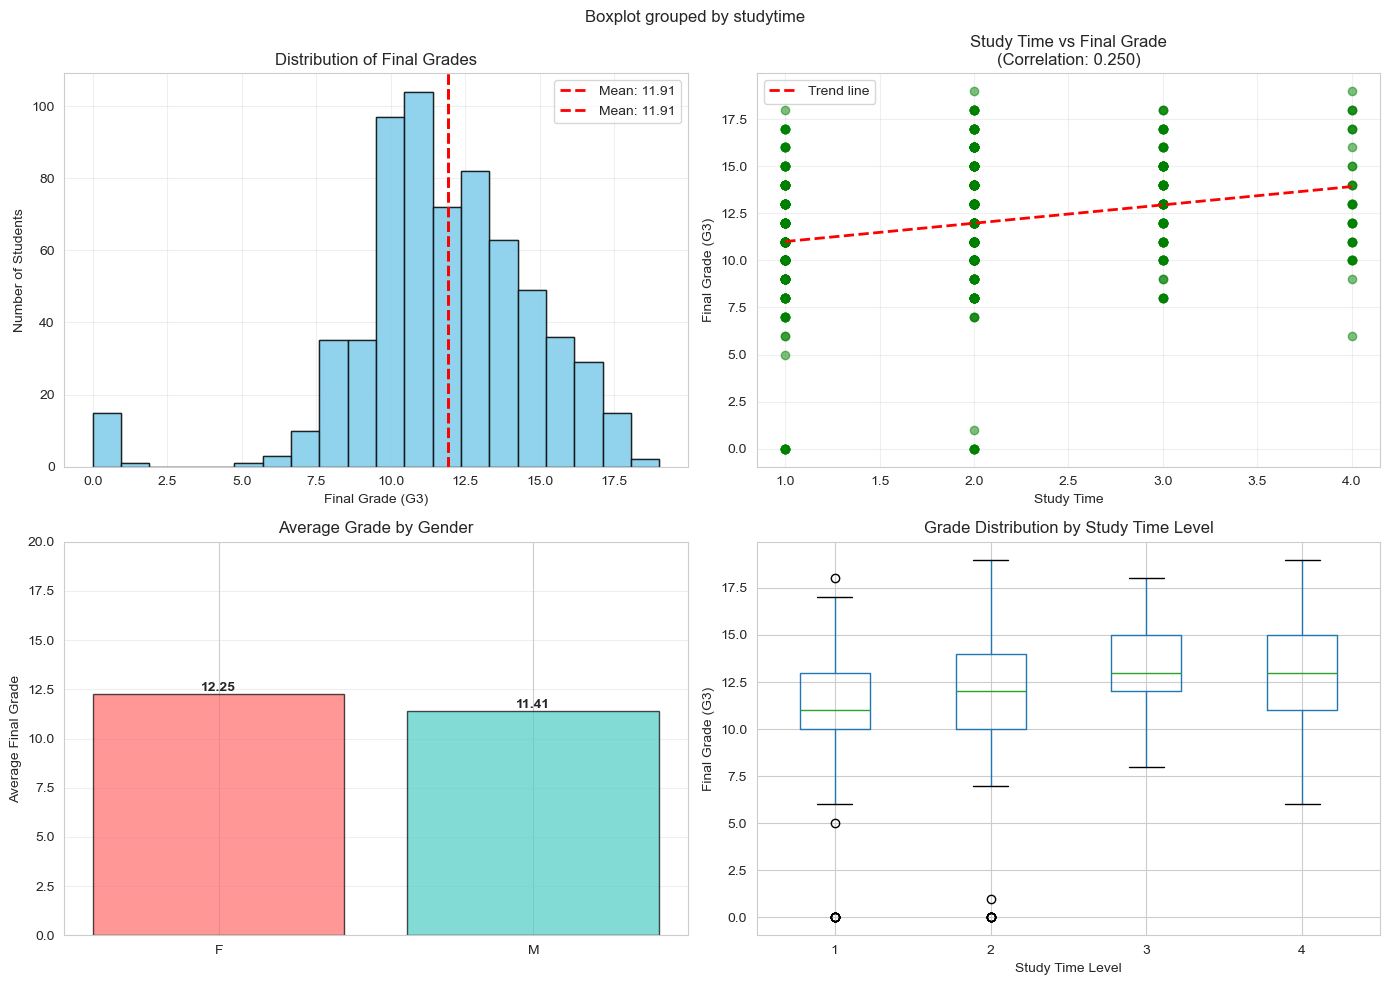

In [34]:
df['studytime'].value_counts().sort_index()
df.boxplot(column='G3', by='studytime', ax=axes[1, 1])
axes[1, 1].set_xlabel('Study Time Level')
axes[1, 1].set_ylabel('Final Grade (G3)')
axes[1, 1].set_title('Grade Distribution by Study Time Level')
plt.sca(axes[1, 1])
plt.xticks(rotation=0)
 
plt.tight_layout()
plt.savefig('student_performance_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualizations created and saved as 'student_performance_analysis.png'")
plt.show()

In [35]:
print("\n" + "="*60)
print("STEP 6: SUMMARY & CONCLUSIONS")
print("="*60)


STEP 6: SUMMARY & CONCLUSIONS


In [36]:
summary = f"""
KEY FINDINGS:
 
1. AVERAGE PERFORMANCE
   • Average final grade: {avg_grade:.2f}/20
 
2. HIGH ACHIEVERS
   • {students_above_15} students ({percentage:.1f}%) scored above 15
 
3. STUDY TIME IMPACT
   • Correlation between study time and grades: {correlation:.3f}
   • This indicates a {'strong' if abs(correlation) > 0.5 else 'moderate' if abs(correlation) > 0.3 else 'weak'} relationship
 
4. GENDER COMPARISON
   • {better_gender} students perform better on average
   • Difference: {abs(avg_by_gender.iloc[0] - avg_by_gender.iloc[1]):.2f} points
 
5. DATA QUALITY
   • Total students analyzed: {len(df)}
   • Missing values: None
   • Duplicates removed: {duplicates}
"""
 
print(summary)
 

print("\nADDITIONAL INSIGHTS:")
print(f"• Highest grade achieved: {df['G3'].max()}")
print(f"• Lowest grade achieved: {df['G3'].min()}")
print(f"• Standard deviation: {df['G3'].std():.2f}")
print(f"• Median grade: {df['G3'].median():.2f}")
 
print("\n✓ Analysis complete!")


KEY FINDINGS:

1. AVERAGE PERFORMANCE
   • Average final grade: 11.91/20

2. HIGH ACHIEVERS
   • 82 students (12.6%) scored above 15

3. STUDY TIME IMPACT
   • Correlation between study time and grades: 0.250
   • This indicates a weak relationship

4. GENDER COMPARISON
   • F students perform better on average
   • Difference: 0.85 points

5. DATA QUALITY
   • Total students analyzed: 649
   • Missing values: None
   • Duplicates removed: 0


ADDITIONAL INSIGHTS:
• Highest grade achieved: 19
• Lowest grade achieved: 0
• Standard deviation: 3.23
• Median grade: 12.00

✓ Analysis complete!
